In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

In [2]:
X_sym, Y_sym = sp.symbols('X Y')

eq1 = -0.5 * Y_sym * (1+X_sym) + X_sym * (1-4*X_sym**2-Y_sym**2)
eq2 = 2 * X_sym * (1+X_sym) + Y_sym * (1-4*X_sym**2-Y_sym**2)

equilibrios = sp.solve((eq1, eq2), (X_sym, Y_sym))
print(f'Equilibrios: {equilibrios}')

Equilibrios: [(-1.00000000000000, -1.73205080756888*I), (-1.00000000000000, 1.73205080756888*I), (0.0, 0.0), (-1.0 - 1.0*I, 2.0 - 2.0*I), (-1.0 + 1.0*I, 2.0 + 2.0*I)]


In [3]:
# Sistema
def sistema(estado):
    x, y = estado
    dXdt = -0.5 * y * (1+x) + x * (1-4*x**2-y**2)
    dYdt = 2 * x * (1+x) + y * (1-4*x**2-y**2)
    return np.array([dXdt, dYdt])

In [4]:
def euler(x0, y0, t0, tf, h):
    num_pasos = int((tf-t0)/h)
    t = np.linspace(t0, tf, num_pasos+1)
    
    X = np.zeros(num_pasos+1)
    X[0] = x0
    Y = np.zeros(num_pasos+1)
    Y[0] = y0 
    
    for i in range(num_pasos):
        estado = np.array([X[i], Y[i]])
        pendiente = sistema(estado)
        
        X[i+1] = X[i] + h * pendiente[0]
        Y[i+1] = Y[i] + h * pendiente[1]
        
    return t, X, Y

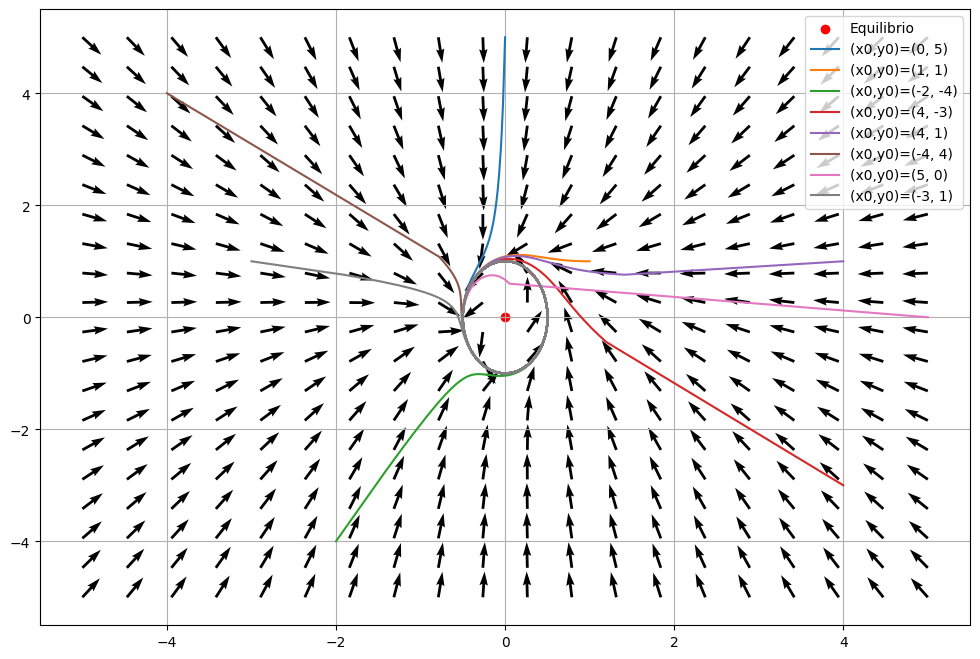

In [16]:
# Campo vectorial
x_vals = np.linspace(-5, 5, 20)
y_vals = np.linspace(-5, 5, 20)
X_grid, Y_grid = np.meshgrid(x_vals, y_vals)

U = -0.5 * Y_grid * (1+X_grid) + X_grid * (1-4*X_grid**2-Y_grid**2)
V = 2 * X_grid * (1+X_grid) + Y_grid * (1-4*X_grid**2-Y_grid**2)

norma = np.sqrt(U**2 + V**2)
norma[norma == 0] = 1

U_norm = U / norma
V_norm = V / norma

plt.figure(figsize=(12,8))
plt.quiver(X_grid, Y_grid, U_norm, V_norm)
plt.scatter(0, 0, label='Equilibrio', color='red')

condiciones_iniciales = [[0,5],[1,1],[-2,-4],[4,-3],[4,1],[-4,4],[5,0],[-3,1]]

for x0, y0 in condiciones_iniciales:
    t, x, y = euler(x0, y0, 0, 100, 0.01)
    plt.plot(x, y, label=f'(x0,y0)={x0,y0}')
    
plt.grid(True)
plt.legend()
plt.show()

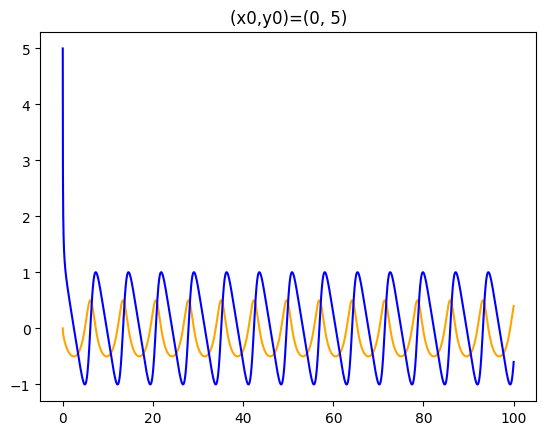

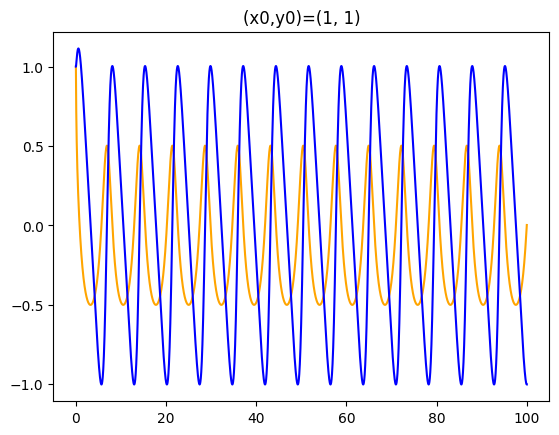

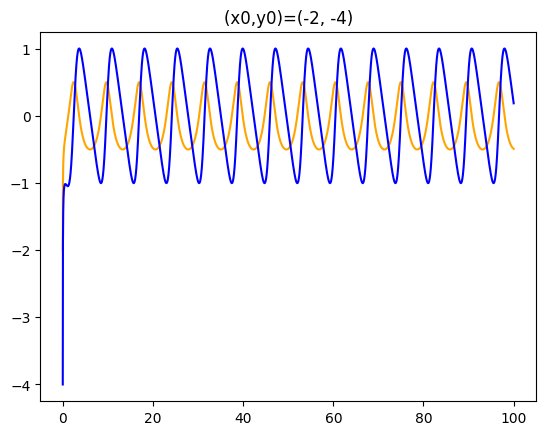

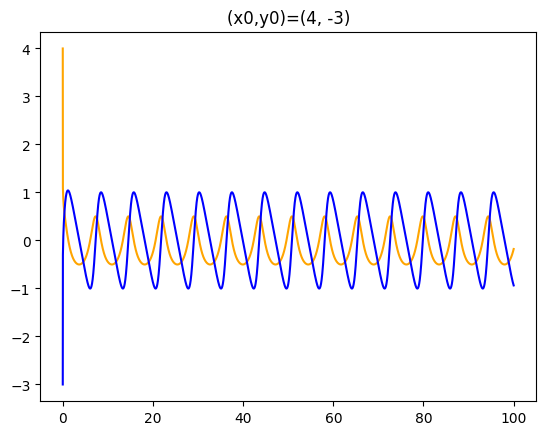

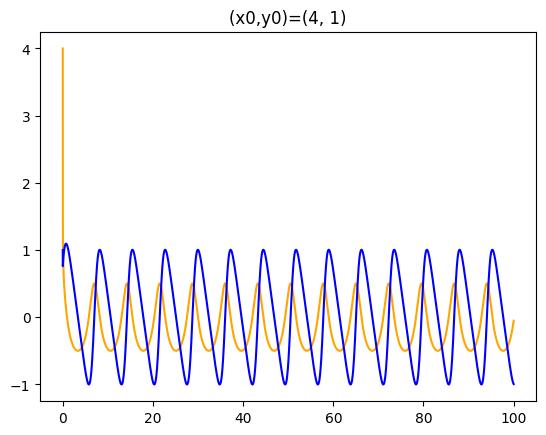

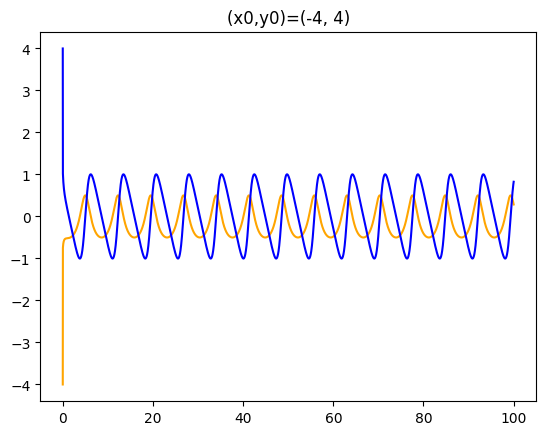

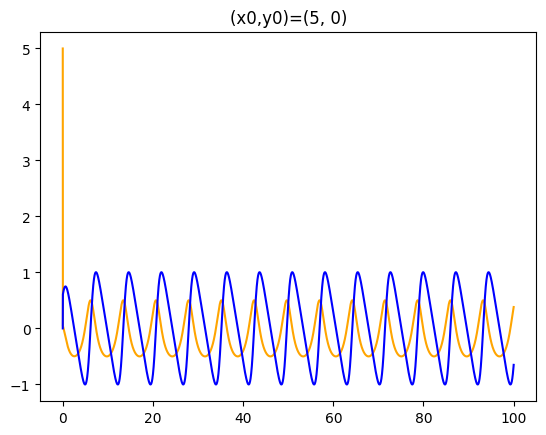

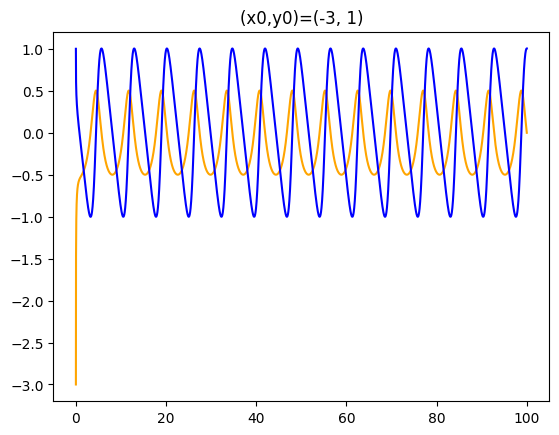

In [17]:
for x0, y0 in condiciones_iniciales:
    t, x, y = euler(x0, y0, 0, 100, 0.01)
    plt.plot(t, x, label='x(t)', color='orange')
    plt.plot(t, y, label='y(t)', color='blue')
    plt.title(f'(x0,y0)={x0,y0}')
    plt.show()